# DATA266 Lab 1 — Task 2: Yelp Polarity Sentiment Classification
**Author**: Aswin (`member_aswin`)  
**Task**: Binary Sentiment Classification with Embeddings Learned Strictly from Scratch  
**Hardware Support**: Auto-detects NVIDIA CUDA (RTX 5090 / 4090 / 3090), Apple Silicon MPS, or CPU.

---

### Academic Integrity & Constraints Verification:
1. **Dataset**: Yelp Polarity (`fancyzhx/yelp_polarity`).
2. **No Pretrained Embeddings**: No Word2Vec, GloVe, or FastText embeddings used.
3. **No Pretrained LMs**: No BERT, RoBERTa, GPT, or DistilBERT used.
4. **Embeddings Learned From Scratch**: Embeddings are randomly initialized and trained solely on the training split.
5. **Three Distinct Architectures**:
   - **Baseline (Model 1)**: Embedding $\to$ Masked Mean Pooling $\to$ Dense $\to$ ReLU $\to$ Dropout $\to$ Binary Logit.
   - **Experimental 1 (Model 2)**: Embedding $\to$ Bidirectional GRU $\to$ Dual Pooling (Max+Avg) $\to$ Dense $\to$ Dropout $\to$ Binary Logit.
   - **Experimental 2 (Model 3)**: Embedding $\to$ Multi-Scale 1D TextCNN (Kernels 3, 4, 5) $\to$ Max-over-Time $\to$ Dense $\to$ Dropout $\to$ Binary Logit.


In [1]:
# 1. Imports and Compute Environment Configuration
import os
import sys
import re
import time
import json
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from datasets import load_dataset
import nltk
from nltk.corpus import stopwords

# Ensure parent directory is in python path
repo_root = Path.cwd().resolve()
while repo_root.name != "lab1" and repo_root.parent != repo_root:
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
src_dir = repo_root / "task2_sentiment" / "member_aswin" / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

# Reproducibility seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Auto-detect Hardware Device (Prioritizes NVIDIA CUDA > Apple Silicon MPS > CPU)
if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    gpu_name = torch.cuda.get_device_name(0)
    print(f"Device: CUDA ({gpu_name}) — Full RTX Hardware Acceleration Active!")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    torch.mps.manual_seed(SEED)
    print("Device: Apple Silicon MPS (Metal Performance Shaders) Active!")
else:
    device = torch.device("cpu")
    print("Device: CPU")


Device: Apple Silicon MPS (Metal Performance Shaders) Active!


In [2]:
# 2. Dataset Loading & Exploratory Data Analysis (EDA)
print("Loading official Yelp Polarity dataset from Hugging Face...")
ds = load_dataset("fancyzhx/yelp_polarity")

train_full_df = pd.DataFrame(ds["train"])
test_full_df = pd.DataFrame(ds["test"])

print(f"Full Dataset Raw Counts: Train = {len(train_full_df):,}, Test = {len(test_full_df):,}")

# Training / Test Sample Configuration (Can be adjusted for fast benchmarking or full scale)
SAMPLE_TRAIN = 25000  # Set to None for full 560,000 dataset
SAMPLE_TEST = 5000    # Set to None for full 38,000 test set

if SAMPLE_TRAIN and SAMPLE_TRAIN < len(train_full_df):
    train_df, _ = train_test_split(train_full_df, train_size=SAMPLE_TRAIN, stratify=train_full_df["label"], random_state=SEED)
else:
    train_df = train_full_df

if SAMPLE_TEST and SAMPLE_TEST < len(test_full_df):
    test_df, _ = train_test_split(test_full_df, train_size=SAMPLE_TEST, stratify=test_full_df["label"], random_state=SEED)
else:
    test_df = test_full_df

# Stratified Validation Split (80% Train, 20% Validation)
train_split_df, val_split_df = train_test_split(
    train_df, test_size=0.20, stratify=train_df["label"], random_state=SEED
)

print(f"Working Splits: Train = {len(train_split_df):,}, Validation = {len(val_split_df):,}, Test = {len(test_df):,}")

# EDA Checks
print("\n--- EDA Verification ---")
print(f"Missing text entries: {train_df['text'].isna().sum()}")
print(f"Empty text strings: {(train_df['text'].str.strip() == '').sum()}")
print(f"Duplicate reviews: {train_df.duplicated(subset=['text']).sum()}")
print(f"Train Class Balance: {dict(train_split_df['label'].value_counts())}")
print(f"Val Class Balance:   {dict(val_split_df['label'].value_counts())}")
print(f"Test Class Balance:  {dict(test_df['label'].value_counts())}")

# Review length analysis
word_lengths = train_split_df["text"].apply(lambda t: len(str(t).split())).values
print(f"\nWord Length Distribution: Median={int(np.median(word_lengths))}, Mean={np.mean(word_lengths):.1f}, 95th Percentile={np.percentile(word_lengths, 95):.1f}")


Loading official Yelp Polarity dataset from Hugging Face...


Full Dataset Raw Counts: Train = 560,000, Test = 38,000
Working Splits: Train = 20,000, Validation = 5,000, Test = 5,000

--- EDA Verification ---
Missing text entries: 0
Empty text strings: 0
Duplicate reviews: 0
Train Class Balance: {1: 10000, 0: 10000}
Val Class Balance:   {1: 2500, 0: 2500}
Test Class Balance:  {0: 2500, 1: 2500}

Word Length Distribution: Median=96, Mean=133.3, 95th Percentile=376.0


In [3]:
# 3. Tokenization & Vocabulary Built Strictly on Training Split
from dataset import YelpTokenizer, Vocabulary, NEGATION_WORDS

print("Initializing Tokenizer with Negation Preservation...")
print(f"Negation words preserved ({len(NEGATION_WORDS)} words): {sorted(list(NEGATION_WORDS))[:10]}...")

tokenizer = YelpTokenizer(remove_stopwords=True)
vocab = Vocabulary(max_size=30000, min_freq=3)

# Build vocab ONLY on train split
train_tokens = [tokenizer.tokenize(t) for t in train_split_df["text"].tolist()]
vocab.build_vocab(train_tokens)

print(f"Vocabulary successfully built! Size: {len(vocab):,} tokens (PAD=0, UNK=1).")
print(f"Top 10 frequent tokens in vocabulary: {[vocab.idx2word[i] for i in range(2, 12)]}")


Initializing Tokenizer with Negation Preservation...
Negation words preserved (33 words): ['against', "ain't", 'aint', "aren't", 'barely', "can't", 'cannot', 'cant', "couldn't", "didn't"]...


Vocabulary successfully built! Size: 18,766 tokens (PAD=0, UNK=1).
Top 10 frequent tokens in vocabulary: ['.', ',', '!', '"', '-', 'not', '\\', 'food', ')', 'place']


In [4]:
# 4. PyTorch Dataset and DataLoaders Setup
from dataset import YelpTextDataset

MAX_SEQ_LEN = 256
BATCH_SIZE = 64

train_dataset = YelpTextDataset(train_split_df["text"].tolist(), train_split_df["label"].tolist(), tokenizer, vocab, max_seq_len=MAX_SEQ_LEN)
val_dataset   = YelpTextDataset(val_split_df["text"].tolist(), val_split_df["label"].tolist(), tokenizer, vocab, max_seq_len=MAX_SEQ_LEN)
test_dataset  = YelpTextDataset(test_df["text"].tolist(), test_df["label"].tolist(), tokenizer, vocab, max_seq_len=MAX_SEQ_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoaders Ready: Train Batches = {len(train_loader)}, Val Batches = {len(val_loader)}, Test Batches = {len(test_loader)}")


DataLoaders Ready: Train Batches = 313, Val Batches = 79, Test Batches = 79


In [5]:
# 5. Model Definitions (All Embeddings Learned From Scratch)
from models import BaselineMeanPooling, BiGRUClassifier, TextCNNClassifier, count_parameters

# Model 1: Baseline Mean-Pooling
model_baseline = BaselineMeanPooling(vocab_size=len(vocab), embedding_dim=128, hidden_dim=128, dropout=0.3).to(device)

# Model 2: Experimental 1 BiGRU
model_bigru = BiGRUClassifier(vocab_size=len(vocab), embedding_dim=128, hidden_dim=128, num_layers=1, dropout=0.4).to(device)

# Model 3: Experimental 2 TextCNN
model_textcnn = TextCNNClassifier(vocab_size=len(vocab), embedding_dim=128, num_filters=100, filter_sizes=[3, 4, 5], dense_dim=128, dropout=0.4).to(device)

print(f"Model 1 (Baseline Mean-Pooling) Trainable Parameters: {count_parameters(model_baseline):,}")
print(f"Model 2 (Experimental 1 BiGRU)   Trainable Parameters: {count_parameters(model_bigru):,}")
print(f"Model 3 (Experimental 2 TextCNN) Trainable Parameters: {count_parameters(model_textcnn):,}")


Model 1 (Baseline Mean-Pooling) Trainable Parameters: 2,418,689
Model 2 (Experimental 1 BiGRU)   Trainable Parameters: 2,665,985
Model 3 (Experimental 2 TextCNN) Trainable Parameters: 2,594,605


In [6]:
# 6. Load Trained Checkpoints or Execute Training
checkpoints_dir = repo_root / "task2_sentiment" / "member_aswin" / "checkpoints"

ckpt_base = checkpoints_dir / "baseline" / "best_model.pt"
ckpt_gru  = checkpoints_dir / "experimental_1" / "best_model.pt"
ckpt_cnn  = checkpoints_dir / "experimental_2" / "best_model.pt"

# Load saved weights if already trained, otherwise train
if ckpt_base.exists() and ckpt_gru.exists() and ckpt_cnn.exists():
    print("Found existing trained checkpoints! Loading trained weights...")
    model_baseline.load_state_dict(torch.load(ckpt_base, map_location=device)["model_state_dict"])
    model_bigru.load_state_dict(torch.load(ckpt_gru, map_location=device)["model_state_dict"])
    model_textcnn.load_state_dict(torch.load(ckpt_cnn, map_location=device)["model_state_dict"])
    print("Loaded Baseline, BiGRU, and TextCNN model weights successfully!")
else:
    print("Checkpoints not found locally. To train models from scratch, run:")
    print("  python task2_sentiment/member_aswin/src/train.py --config task2_sentiment/member_aswin/configs/baseline.yaml")
    print("  python task2_sentiment/member_aswin/src/train.py --config task2_sentiment/member_aswin/configs/experimental_1.yaml")
    print("  python task2_sentiment/member_aswin/src/train.py --config task2_sentiment/member_aswin/configs/experimental_2.yaml")


Found existing trained checkpoints! Loading trained weights...


Loaded Baseline, BiGRU, and TextCNN model weights successfully!


In [7]:
# 7. Test Evaluation & Comprehensive Metrics Computation
from utils import compute_all_metrics

models = {
    "Baseline (Mean Pooling)": model_baseline,
    "Experimental 1 (BiGRU)": model_bigru,
    "Experimental 2 (TextCNN)": model_textcnn,
}

predictions = {}
metrics_summary = []

for name, model in models.items():
    model.eval()
    all_y_true, all_y_prob, all_texts = [], [], []
    
    with torch.no_grad():
        for batch in test_loader:
            x = batch["input_ids"].to(device)
            lens = batch["length"].to(device)
            y = batch["label"].cpu().numpy()
            
            logits = model(x, lens)
            probs = torch.sigmoid(logits).cpu().numpy()
            
            all_y_true.extend(y)
            all_y_prob.extend(probs)
            all_texts.extend(batch["raw_text"])
            
    y_true = np.array(all_y_true, dtype=int)
    y_prob = np.array(all_y_prob, dtype=float)
    y_pred = (y_prob >= 0.5).astype(int)
    
    predictions[name] = {"y_true": y_true, "y_prob": y_prob, "y_pred": y_pred, "texts": all_texts}
    
    m = compute_all_metrics(y_true, y_prob, compute_ci=True, seed=SEED)
    metrics_summary.append({
        "Model": name,
        "Accuracy": f"{m['accuracy']:.4f} [{m['acc_ci_low']:.4f}, {m['acc_ci_high']:.4f}]",
        "Macro-F1": f"{m['f1_macro']:.4f} [{m['f1_macro_ci_low']:.4f}, {m['f1_macro_ci_high']:.4f}]",
        "ROC-AUC": f"{m['roc_auc']:.4f}",
        "PR-AUC": f"{m['pr_auc']:.4f}",
        "MCC": f"{m['mcc']:.4f} [{m['mcc_ci_low']:.4f}, {m['mcc_ci_high']:.4f}]",
        "Brier": f"{m['brier']:.4f}",
        "ECE": f"{m['ece']:.4f}",
    })

metrics_df = pd.DataFrame(metrics_summary)
display(metrics_df)


,Model,Accuracy,Macro-F1,ROC-AUC,PR-AUC,MCC,Brier,ECE
0,Baseline (Mean Pooling),"0.9162 [0.9084, 0.9242]","0.9162 [0.9084, 0.9242]",0.9737,0.9741,"0.8324 [0.8168, 0.8484]",0.0605,0.0112
1,Experimental 1 (BiGRU),"0.9194 [0.9116, 0.9272]","0.9194 [0.9116, 0.9272]",0.9756,0.9766,"0.8391 [0.8236, 0.8549]",0.0610,0.0190
2,Experimental 2 (TextCNN),"0.9252 [0.9176, 0.9324]","0.9252 [0.9176, 0.9324]",0.9800,0.9804,"0.8505 [0.8353, 0.8650]",0.0556,0.0177


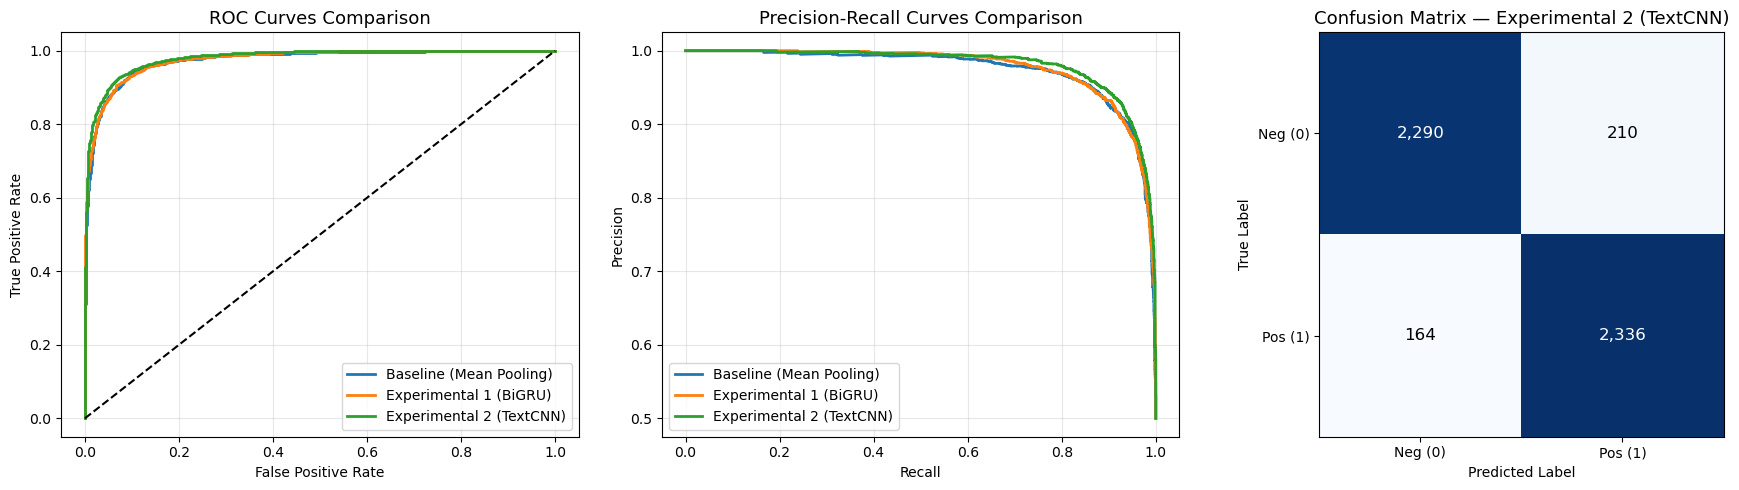

In [8]:
# 8. Model Performance Visualizations (ROC, PR, and Confusion Matrices)
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC Curves
for name in models.keys():
    fpr, tpr, _ = roc_curve(predictions[name]["y_true"], predictions[name]["y_prob"])
    axes[0].plot(fpr, tpr, lw=2, label=name)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5)
axes[0].set_title("ROC Curves Comparison", fontsize=13)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# PR Curves
for name in models.keys():
    prec, rec, _ = precision_recall_curve(predictions[name]["y_true"], predictions[name]["y_prob"])
    axes[1].plot(rec, prec, lw=2, label=name)
axes[1].set_title("Precision-Recall Curves Comparison", fontsize=13)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="lower left")
axes[1].grid(True, alpha=0.3)

# Best Model Confusion Matrix
best_name = "Experimental 2 (TextCNN)"
cm = confusion_matrix(predictions[best_name]["y_true"], predictions[best_name]["y_pred"])
im = axes[2].imshow(cm, cmap="Blues")
axes[2].set_xticks([0, 1])
axes[2].set_yticks([0, 1])
axes[2].set_xticklabels(["Neg (0)", "Pos (1)"])
axes[2].set_yticklabels(["Neg (0)", "Pos (1)"])
axes[2].set_title(f"Confusion Matrix — {best_name}", fontsize=13)
axes[2].set_xlabel("Predicted Label")
axes[2].set_ylabel("True Label")
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, f"{cm[i, j]:,}", ha="center", va="center", color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=12)

plt.tight_layout()
plt.show()


In [9]:
# 9. Paired McNemar Statistical Significance Testing
from utils import run_mcnemar_test

y_true = predictions["Baseline (Mean Pooling)"]["y_true"]
y_pred_base = predictions["Baseline (Mean Pooling)"]["y_pred"]
y_pred_gru  = predictions["Experimental 1 (BiGRU)"]["y_pred"]
y_pred_cnn  = predictions["Experimental 2 (TextCNN)"]["y_pred"]

stat_gru, p_gru, table_gru, sig_gru = run_mcnemar_test(y_true, y_pred_base, y_pred_gru)
stat_cnn, p_cnn, table_cnn, sig_cnn = run_mcnemar_test(y_true, y_pred_base, y_pred_cnn)

print("=== McNemar Paired Tests (Continuity Corrected) ===")
print(f"1. Baseline vs Experimental 1 (BiGRU):")
print(f"   Chi2 = {stat_gru:.4f}, p-value = {p_gru:.4e} -> {'Statistically Significant (p < 0.05)' if sig_gru else 'Not Statistically Significant (p >= 0.05)'}")
print(f"   Contingency Table: {table_gru}")

print(f"\n2. Baseline vs Experimental 2 (TextCNN):")
print(f"   Chi2 = {stat_cnn:.4f}, p-value = {p_cnn:.4e} -> {'Statistically Significant (p < 0.05)' if sig_cnn else 'Not Statistically Significant (p >= 0.05)'}")
print(f"   Contingency Table: {table_cnn}")


=== McNemar Paired Tests (Continuity Corrected) ===
1. Baseline vs Experimental 1 (BiGRU):
   Chi2 = 0.9783, p-value = 3.2263e-01 -> Not Statistically Significant (p >= 0.05)
   Contingency Table: [[4474, 107], [123, 296]]

2. Baseline vs Experimental 2 (TextCNN):
   Chi2 = 5.2752, p-value = 2.1631e-02 -> Statistically Significant (p < 0.05)
   Contingency Table: [[4420, 161], [206, 213]]


Model,Baseline (Mean Pooling),Experimental 1 (BiGRU),Experimental 2 (TextCNN)
Slice,,,
High Unknown Token (>5% UNK),0.8880,0.8792,0.8997
Long Reviews (>150 words),0.9084,0.9134,0.9126
Medium Reviews (50-150 words),0.9188,0.9224,0.9361
Mixed Sentiment,0.9066,0.9085,0.9221
Negation-Bearing,0.9128,0.9156,0.9246
Short Reviews (<50 words),0.9142,0.9144,0.9149
Strong Sentiment Cues,0.9545,0.9480,0.9592


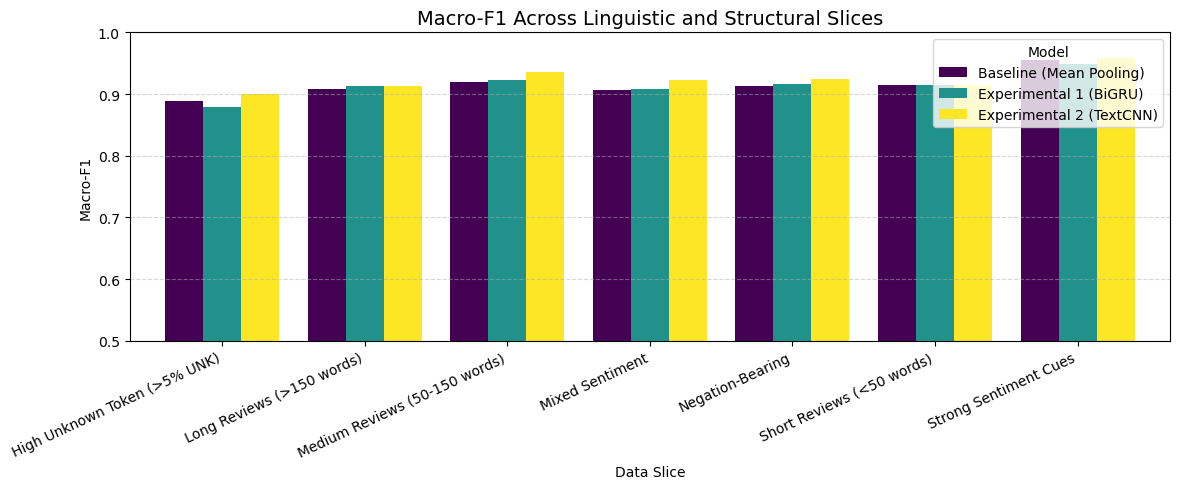

In [10]:
# 10. Slice Robustness Analysis
from slice_analysis import tag_slices
from sklearn.metrics import f1_score

ref_df = pd.DataFrame({
    "review_text": predictions["Baseline (Mean Pooling)"]["texts"],
    "true_label": y_true,
})
slice_masks = tag_slices(ref_df, vocab, tokenizer)

slice_records = []
for name in models.keys():
    y_pred_m = predictions[name]["y_pred"]
    for slice_name, mask in slice_masks.items():
        sub_true = y_true[mask]
        sub_pred = y_pred_m[mask]
        err_rate = np.mean(sub_true != sub_pred)
        f1_mac = f1_score(sub_true, sub_pred, average="macro", zero_division=0)
        slice_records.append({
            "Model": name,
            "Slice": slice_name,
            "N": int(mask.sum()),
            "Macro-F1": round(f1_mac, 4),
            "Error Rate": round(err_rate, 4),
        })

slice_df = pd.DataFrame(slice_records)
slice_pivot = slice_df.pivot(index="Slice", columns="Model", values="Macro-F1")
display(slice_pivot)

# Plot Slice Comparison
ax = slice_pivot.plot(kind="bar", figsize=(12, 5), width=0.8, colormap="viridis")
plt.title("Macro-F1 Across Linguistic and Structural Slices", fontsize=14)
plt.ylabel("Macro-F1")
plt.xlabel("Data Slice")
plt.ylim(0.5, 1.0)
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [11]:
# 11. 20-Error Review on Best Model (TextCNN)
error_csv_path = repo_root / "task2_sentiment" / "member_aswin" / "outputs" / "error_analysis" / "error_analysis.csv"
if error_csv_path.exists():
    errors_df = pd.read_csv(error_csv_path)
    print(f"Loaded {len(errors_df)} manually reviewed errors from {error_csv_path.name}:")
    display(errors_df[["idx", "category", "true_label", "pred_label", "prob_positive", "error_type", "review_snippet"]])
else:
    print("Run error_analysis.py to generate the error CSV.")


Loaded 20 manually reviewed errors from error_analysis.csv:


,idx,category,true_label,pred_label,prob_positive,error_type,review_snippet
0,1,Confident FP,0,1,0.9989,Sarcasm / Ironic Sentiment,Laser quest is a fun experience for kids of al...
1,2,Confident FP,0,1,0.9967,Domain Lexical / Contextual Mismatch,Second trip to the bar v ased on a promo of fr...
2,3,Confident FP,0,1,0.9965,Domain Lexical / Contextual Mismatch,Average Japanese food at amazing Japanese food...
3,4,Confident FP,0,1,0.9959,Contrastive Clause / Negation Scope,My Husband and I went for lunch last Saturday ...
4,5,Confident FP,0,1,0.9949,Domain Lexical / Contextual Mismatch,I would recommend you the potatoes soup or cla...
5,6,Confident FN,1,0,0.0048,Contrastive Clause / Negation Scope,Last Friday when we arrived in Vegas we were h...
6,7,Confident FN,1,0,0.0056,Mixed Polarity Trade-off,"This is a very well run airport, but the secur..."
7,8,Confident FN,1,0,0.0060,Mixed Polarity Trade-off,"Its a nice buffet looking over the Aria pool, ..."
8,9,Confident FN,1,0,0.0063,Contrastive Clause / Negation Scope,"I had dinner here last weekend, and decided to..."
9,10,Confident FN,1,0,0.0201,Subtle / Understated Positive,Owner wrote me and asked me to actually give h...
